# ***1차시***
## ***거대언어모델(LLM)의 동작 원리***

### ***데이터와 학습***
- 이차방정식 곡선의 점들을 데이터로 하여 이들을 학습시켜보겠습니다
- 여러개 (x, y) 점의 쌍을 보여주면 그 패턴을 학습하여 이차방정식 곡선의 점을 찍을 수 있음을 확인합니다
- 문장을 x, y와 같은 숫자의 시퀀스로 변환할 수 있음을 확인합니다
- 문장을 x, y와 같은 숫자의 시퀀스로 변환하여 벡터화하고(임베딩) 학습해봅니다

In [3]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


data_size = 100  # 10,100,500,1000 등 조절 가능

def get_data(data_size=100):

    np.random.seed(42)
    x = np.random.uniform(-10, 10, data_size).reshape(-1, 1).astype(np.float32)
    y = (2 * x**2 + 3 * x + 4).astype(np.float32)

    # 학습/테스트 분리
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

    num_samples = 10
    print('==============학습데이터==================')
    for xi, yi in zip(x_train[:num_samples], y_train[:num_samples]):
        print(f"({xi}, {yi})")
    print('========================================')
    print()
    print('==============테스트데이터==================')
    for xi, yi in zip(x_test[:num_samples], y_test[:num_samples]):
        print(f"({xi}, {yi})")
    print('========================================')

    return x_train, x_test, y_train, y_test

x_train, x_test, y_train, y_test  = get_data(100)

==============학습데이터==================
([8.437485], [171.69475])
([7.744255], [147.17975])
([-6.0065246], [58.137104])
([-9.312229], [149.49854])
([9.737739], [222.86032])
([-6.3319097], [65.19043])
([-7.559235], [95.60637])
([0.4546566], [5.7773952])
([4.1614513], [51.119705])
([-9.889558], [169.93803])

==============테스트데이터==================
([-8.728833], [130.19855])
([7.896547], [152.40054])
([5.4448953], [79.628456])
([3.2504456], [34.88213])
([-4.8244004], [36.076477])
([-1.1969501], [3.2745287])
([-4.157107], [26.091755])
([7.2620687], [131.26149])
([-9.58831], [159.10645])
([-2.5091977], [9.064552])


## ***학습 데이터 시각화***

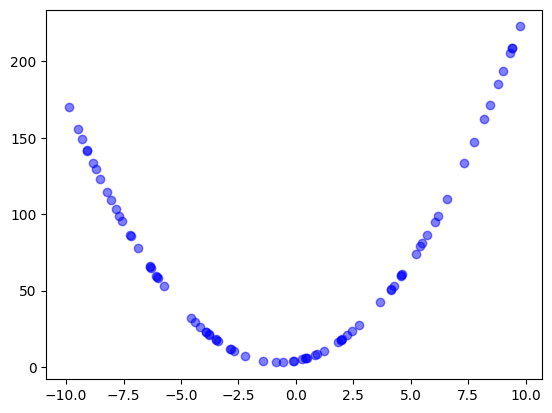

In [4]:
plt.scatter(x_train, y_train, color='blue', label='Train data', alpha=0.5)
plt.show()

### ***테스트 데이터 시각화***

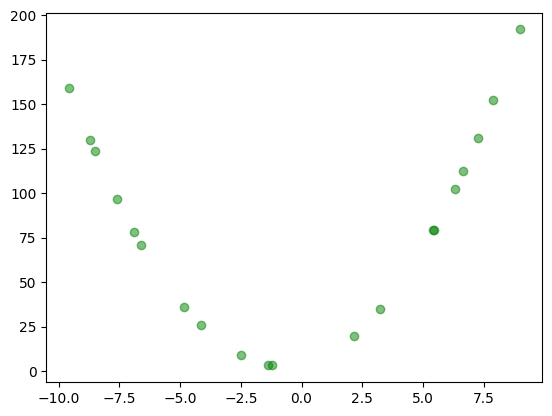

In [5]:
plt.scatter(x_test, y_test, color='green', label='Test data', alpha=0.5)
plt.show()

### ***데이터의 양과 반복 학습 횟수를 늘리면서 학습해보기***

==============학습데이터==================
([-6.88011], [78.031494])
([-2.5091977], [9.064552])
([7.323523], [133.23856])
([4.6398787], [60.976585])
([4.1614513], [51.119705])
([-6.879627], [78.01965])
([1.9731697], [17.706306])
([-8.838327], [133.71707])

==============테스트데이터==================
([2.0223002], [18.246298])
([9.014286], [193.55757])


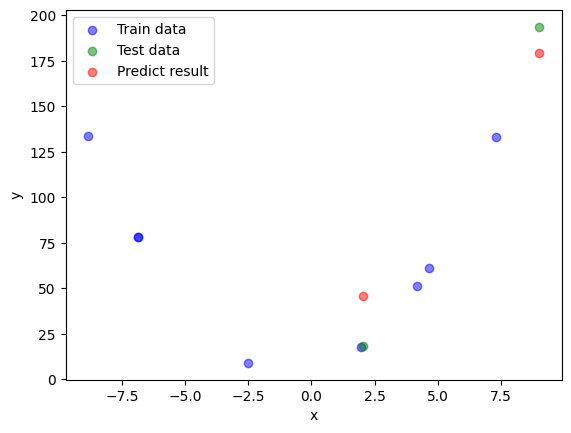

In [6]:
# 아래 두 항목을 늘리면서 테스트 해봅시다
date_size = 10 # 100, 1000, 10000
epochs = 10 # 100, 500, 1000

x_train, x_test, y_train, y_test = get_data(date_size)

# NumPy → Torch Tensor
x_train = torch.from_numpy(x_train)
y_train = torch.from_numpy(y_train)
x_test = torch.from_numpy(x_test)
y_test = torch.from_numpy(y_test)

class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(1, 64)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

model = SimpleNN()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.1)

# 학습 루프
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(x_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

    # 100 epoch마다 loss 출력
    if (epoch+1) % 100 == 0:
        print(f'Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}')

# 테스트 예측
model.eval()
with torch.no_grad():
    y_pred_test = model(x_test)


# 시각화
plt.scatter(x_train.numpy(), y_train.numpy(), color='blue', label='Train data', alpha=0.5)
plt.scatter(x_test.numpy(), y_test.numpy(), color='green', label='Test data', alpha=0.5)
plt.scatter(x_test.numpy(), y_pred_test.numpy(), color='red', label='Predict result', alpha=0.5)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

## ***여기서 알수 있는 것***
- 데이터로 함수를 만들 수 있습니다
- 데이터의 양이 많아지면 좀더 정확한 함수를 만들 수 있습니다
- 적당히 반복 학습을 하면 좀더 정확한 함수를 만들 수 있습니다

## ***지금부터 진행할 내용***
- 우리의 단어를 숫자로 바꾸는 무언가를 만들어봅니다 (이를 Tokenizer라고 합니다)
- 그러면 이 숫자들도 학습될 수 있음을 이해합니다
- 입력 문장 -> 함수 -> 출력 문장(이어질 문장)

### ***Vocab***
- 한글 문자, 영문자, 숫자, 문장부호를 숫자에 매핑시키는 vocab을 만듭니다
- 좀더 강조해서 학습하고 싶은 단어가 있으면 추가해봅니다

In [19]:
# 기본 한글 + 영어 + 숫자
hangul_start = ord("가")
hangul_end = ord("힣")
vocab = {chr(i): i for i in range(hangul_start, hangul_end+1)}
for c in "abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789.?! ":
    vocab[c] = len(vocab)
vocab["<unk>"] = len(vocab)

# 강조 단어 추가
custom_words = ["인공지능", "학습", "데이터"]
for w in custom_words:
    vocab[w] = len(vocab)

# 자모 범위 추가
jamo_ranges = [
    (ord('ㄱ'), ord('ㅣ')),  # 호환 자모 (ㄱ~ㅣ)
]

for start, end in jamo_ranges:
    for i in range(start, end + 1):
        vocab[chr(i)] = len(vocab)

In [8]:
vocab

{'가': 44032,
 '각': 44033,
 '갂': 44034,
 '갃': 44035,
 '간': 44036,
 '갅': 44037,
 '갆': 44038,
 '갇': 44039,
 '갈': 44040,
 '갉': 44041,
 '갊': 44042,
 '갋': 44043,
 '갌': 44044,
 '갍': 44045,
 '갎': 44046,
 '갏': 44047,
 '감': 44048,
 '갑': 44049,
 '값': 44050,
 '갓': 44051,
 '갔': 44052,
 '강': 44053,
 '갖': 44054,
 '갗': 44055,
 '갘': 44056,
 '같': 44057,
 '갚': 44058,
 '갛': 44059,
 '개': 44060,
 '객': 44061,
 '갞': 44062,
 '갟': 44063,
 '갠': 44064,
 '갡': 44065,
 '갢': 44066,
 '갣': 44067,
 '갤': 44068,
 '갥': 44069,
 '갦': 44070,
 '갧': 44071,
 '갨': 44072,
 '갩': 44073,
 '갪': 44074,
 '갫': 44075,
 '갬': 44076,
 '갭': 44077,
 '갮': 44078,
 '갯': 44079,
 '갰': 44080,
 '갱': 44081,
 '갲': 44082,
 '갳': 44083,
 '갴': 44084,
 '갵': 44085,
 '갶': 44086,
 '갷': 44087,
 '갸': 44088,
 '갹': 44089,
 '갺': 44090,
 '갻': 44091,
 '갼': 44092,
 '갽': 44093,
 '갾': 44094,
 '갿': 44095,
 '걀': 44096,
 '걁': 44097,
 '걂': 44098,
 '걃': 44099,
 '걄': 44100,
 '걅': 44101,
 '걆': 44102,
 '걇': 44103,
 '걈': 44104,
 '걉': 44105,
 '걊': 44106,
 '걋': 44107,
 '걌': 44108,

### ***Tokenizer***
- 우리의 문장을 vocab으로부터 longest match 방식으로 변환합니다
- 예를 들어 "인공지능은 어떻게 학습되는가?" 를 tokenizer와 vocab으로 변환하면 아래와 같습니다

In [9]:
# "인공지능" 이라는 단어는 longest match에 의해 아래 "인공지능" 에 매칭됩니다
vocab['인공지능'], vocab['인'], vocab['공'],vocab['지'], vocab['능']

(11239, 51064, 44277, 51648, 45733)

In [12]:
text = "인공지능은 어떻게 학습되는가?"

def tokenize(text, vocab):
    tokens = []
    i = 0
    while i < len(text):
        match = None
        # 가장 긴 단어부터 탐색
        for j in range(len(text), i, -1):
            sub = text[i:j]
            if sub in vocab:
                match = sub
                break
        if match:
            tokens.append(match)
            i += len(match)
        else:
            tokens.append("<unk>")
            i += 1
    return tokens



# 토큰화
tokens = tokenize(text, vocab)

# 토큰 → 숫자(id)
token_ids = [vocab[t] for t in tokens]

print(tokens)
print(token_ids)

['인공지능', '은', ' ', '어', '떻', '게', ' ', '학습', '되', '는', '가', '?']
[11239, 51008, 11237, 50612, 46523, 44172, 11237, 11240, 46104, 45716, 44032, 11235]


## ***vocab과 tokenizer를 이용해 변환된 숫자를 학습시키기***
- 위에서 만든 vocab의 크기는 너무 커서 테스트 용도로 학습하기에는 너무 큽니다
- 아래와 같이 여러 테스트 문장을 적어 이를 베이스로 vocab을 재구성하여 학습합니다

In [117]:
sentences = [
    "나는 밥을 먹는다",
    "나는 학교에 간다",
    "나는 공부를 한다", 
    "오늘 날씨가 좋다",
    "오늘 인공지능을 공부한다"
]

In [118]:
import torch
import torch.nn as nn

def tokenize(text):
    return text.split()

vocab = {}
for s in sentences:
    for w in tokenize(s):
        if w not in vocab:
            vocab[w] = len(vocab) + 1

id_to_word = {i: w for w, i in vocab.items()}

vocab_size = len(vocab)
print("Vocab:", vocab)

Vocab: {'나는': 1, '밥을': 2, '먹는다': 3, '학교에': 4, '간다': 5, '공부를': 6, '한다': 7, '오늘': 8, '날씨가': 9, '좋다': 10, '인공지능을': 11, '공부한다': 12}


#### ***슬라이딩 윈도우 형태의 데이터 세트 생성***

In [109]:
X = []
Y = []

for s in sentences:
    tokens = tokenize(s)
    ids = [vocab[t] for t in tokens]
    for i in range(len(ids)-1):
        X.append(ids[:i+1])
        Y.append(ids[i+1])

print(X)
print(Y)


# sentences = [
#     "나는 밥을 먹는다",
#     "나는 학교에 간다",
#     "나는 공부를 한다", 
#     "오늘 날씨가 좋다",
#     "오늘 인공지능을 공부한다"
# ]
# Vocab: {'나는': 1, '밥을': 2, '먹는다': 3, '학교에': 4, '간다': 5, '공부를': 6, '한다': 7, '오늘': 8, '날씨가': 9, '좋다': 10, '인공지능을': 11, '공부한다': 12}

# 나는,  나는,밥을  나는      나는, 학교에  나는      나는,공부를    오늘      오늘,날씨가       오늘       오늘, 인공지능을
# [[1], [1, 2],   [1],     [1, 4],      [1],     [1, 6],      [8],      [8, 9],         [8],       [8, 11]]

# 밥을   먹는다     학교에    간다         공부를    한다           날씨가    좋다            인공지능을   공부한다
# [2,   3,         4,       5,          6,       7,            9,       10,              11         12]

[[1], [1, 2], [1], [1, 4], [1], [1, 6], [8], [8, 9], [8], [8, 11]]
[2, 3, 4, 5, 6, 7, 9, 10, 11, 12]


#### ***패딩***
- 입력 크기를 맞추기 위해 0을 붙여주는 과정

In [110]:
max_len = max(len(x) for x in X)

def pad(seq):
    return seq + [0]*(max_len - len(seq))

X = [pad(x) for x in X]

for x, y in zip(X, Y):
    print(f"{x} -> {y}")


# Vocab: {'나는': 1, '밥을': 2, '먹는다': 3, '학교에': 4, '간다': 5, '공부를': 6, '한다': 7, '오늘': 8, '날씨가': 9, '좋다': 10, '인공지능을': 11, '공부한다': 12}

# 나는,0    나는,밥을   나는,0      나는, 학교에   나는,0      나는,공부를     오늘,0      오늘,날씨가       오늘,0      오늘, 인공지능을
# [[1,0],   [1, 2],   [1,0],     [1, 4],       [1,0],     [1, 6],       [8,0],      [8, 9],         [8,0],      [8, 11]]

# 밥을      먹는다      학교에     간다          공부를        한다           날씨가      좋다            인공지능을    공부한다
# [2,       3,         4,        5,           6,           7,            9,          10,            11          12]

[1, 0] -> 2
[1, 2] -> 3
[1, 0] -> 4
[1, 4] -> 5
[1, 0] -> 6
[1, 6] -> 7
[8, 0] -> 9
[8, 9] -> 10
[8, 0] -> 11
[8, 11] -> 12


### ***딥러닝으로 함수 만들기(학습하기)***
- 딥러닝에서는 우리가 데이터를 제공하고 컴퓨터가 함수를 만듭니다
    - 입력: 문장
    - 동작: 다음 등장할 단어 계산
    - 출력: 다음 등장할 단어

In [111]:
X_tensor = torch.tensor(X)
y_tensor = torch.tensor(Y)

embedding_dim = 16

model = nn.Sequential(
    nn.Embedding(vocab_size+1, embedding_dim),
    nn.Flatten(),
    nn.Linear(embedding_dim * max_len, 64),
    nn.ReLU(),
    nn.Linear(64, vocab_size+1)
)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

for epoch in range(10):
    pred = model(X_tensor)
    loss = loss_fn(pred, y_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    print(f"Epoch {epoch+1} Loss: {loss.item():.4f}")

Epoch 1 Loss: 2.5884
Epoch 2 Loss: 2.2305
Epoch 3 Loss: 1.9147
Epoch 4 Loss: 1.6257
Epoch 5 Loss: 1.3655
Epoch 6 Loss: 1.1360
Epoch 7 Loss: 0.9428
Epoch 8 Loss: 0.7906
Epoch 9 Loss: 0.6768
Epoch 10 Loss: 0.5960


In [112]:
def generate(start_word, steps=3):
    tokens = [vocab[start_word]]

    for _ in range(steps):
        # 항상 max_len 길이로 padding
        x = tokens[-max_len:]  # 최근 max_len만 사용
        x = pad(x)
        x = torch.tensor([x])

        pred = model(x)
        next_id = pred.argmax().item()
        tokens.append(next_id)

    return " ".join(id_to_word[t] for t in tokens)


print("Generated:", generate("나는"))
print("Generated:", generate("인공지능을"))

Generated: 나는 밥을 먹는다 좋다
Generated: 인공지능을 학교에 간다 먹는다


## ***단어가 벡터로 변환되는 과정 알아보기***
- 위의 학습 과정을 확인해보면 우리의 단어를 8차원 벡터로 변환하여 학습합니다
- 이 벡터또한 학습되면서 변화합니다
- 유사도가 높은 단어들은 비슷한 벡터로 변화하는 것입니다
- 먼저 학습 초기의 벡터 상태를 확인해봅니다

In [113]:
# 간단한 vocab
sentences = [
    "나는 밥을 먹는다",
    "나는 학교에 간다",
    "나는 공부를 한다", 
    "오늘 날씨가 좋다",
    "오늘 인공지능을 공부한다"
]

vocab = {}
for s in sentences:
    for w in tokenize(s):
        if w not in vocab:
            vocab[w] = len(vocab) + 1

id_to_word = {i: w for w, i in vocab.items()}

vocab_size = len(vocab)
print("Vocab:", vocab)

Vocab: {'나는': 1, '밥을': 2, '먹는다': 3, '학교에': 4, '간다': 5, '공부를': 6, '한다': 7, '오늘': 8, '날씨가': 9, '좋다': 10, '인공지능을': 11, '공부한다': 12}


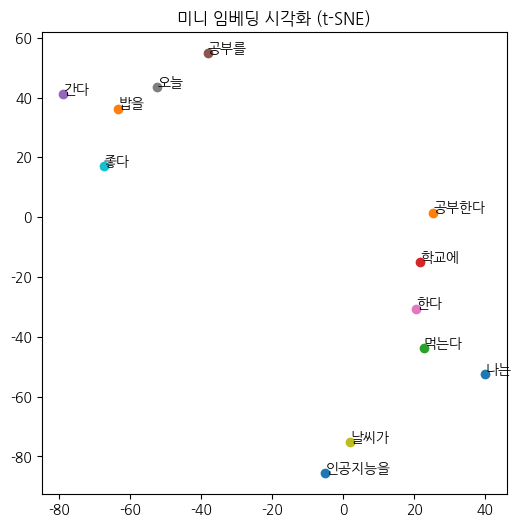

==== 코사인 유사도 행렬 ====
[[ 1.   -0.26  0.39  0.24 -0.59  0.04  0.12 -0.25  0.1   0.23  0.01 -0.26]
 [-0.26  1.   -0.68 -0.15  0.69 -0.07 -0.66  0.31  0.07 -0.08 -0.19 -0.2 ]
 [ 0.39 -0.68  1.   -0.03 -0.65 -0.06  0.46  0.04  0.47 -0.24  0.31 -0.11]
 [ 0.24 -0.15 -0.03  1.   -0.42 -0.31  0.36 -0.43 -0.53 -0.24 -0.46  0.71]
 [-0.59  0.69 -0.65 -0.42  1.    0.19 -0.85  0.18  0.01  0.23  0.08 -0.15]
 [ 0.04 -0.07 -0.06 -0.31  0.19  1.   -0.14  0.49 -0.25  0.38  0.1   0.14]
 [ 0.12 -0.66  0.46  0.36 -0.85 -0.14  1.   -0.07 -0.13 -0.31 -0.08  0.41]
 [-0.25  0.31  0.04 -0.43  0.18  0.49 -0.07  1.    0.02 -0.21 -0.25 -0.08]
 [ 0.1   0.07  0.47 -0.53  0.01 -0.25 -0.13  0.02  1.   -0.3   0.75 -0.68]
 [ 0.23 -0.08 -0.24 -0.24  0.23  0.38 -0.31 -0.21 -0.3   1.   -0.06 -0.08]
 [ 0.01 -0.19  0.31 -0.46  0.08  0.1  -0.08 -0.25  0.75 -0.06  1.   -0.39]
 [-0.26 -0.2  -0.11  0.71 -0.15  0.14  0.41 -0.08 -0.68 -0.08 -0.39  1.  ]]


In [114]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

vocab_size = len(vocab)
word_to_id = {w:i for i,w in enumerate(vocab)}
id_to_word = {i:w for w,i in word_to_id.items()}

# 미니 임베딩 층
embedding_dim = 8
embedding_layer = nn.Embedding(vocab_size, embedding_dim)

# 랜덤 초기화 상태의 임베딩 확인 가능
embeddings = embedding_layer(torch.arange(vocab_size)).detach().numpy()

# t-SNE로 2차원 시각화
tsne = TSNE(n_components=2, perplexity=2, random_state=42)
emb_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(6,6))
for i, w in enumerate(vocab):
    x, y = emb_2d[i]
    plt.scatter(x, y)
    plt.text(x+0.1, y+0.1, w)
plt.title("미니 임베딩 시각화 (t-SNE)")
plt.show()

# 코사인 유사도 계산
cos_sim = cosine_similarity(embeddings)
print("==== 코사인 유사도 행렬 ====")
print(np.round(cos_sim, 2))

학습 시작...
Epoch 50, Loss: 4.9957
Epoch 100, Loss: 4.8940
Epoch 150, Loss: 4.8485
Epoch 200, Loss: 4.8195
학습 완료

==== 학습 후 임베딩 벡터 ====
나는: [-0.955 -0.595 -0.69   2.356  0.639 -0.144  1.402 -1.482]
밥을: [-0.879  1.254  2.19  -2.005  1.198 -1.8   -0.135  0.529]
먹는다: [ 1.384  2.646  0.996  2.429  1.134  0.332 -1.098 -1.38 ]
학교에: [-1.702 -0.563  0.574 -1.035 -0.643  0.162 -1.547  0.87 ]
간다: [-1.155 -1.623  0.982 -1.277  0.233 -2.521  0.345  0.845]
공부를: [ 0.548  0.482 -0.196 -0.434  0.112 -0.61  -1.419 -1.338]
한다: [ 1.741  1.368  1.441 -1.756  0.202 -1.217 -3.812  0.175]
오늘: [ 1.349  0.48   2.065  0.619 -0.348 -0.113 -0.415 -0.737]
날씨가: [-0.672 -0.132 -0.41  -1.269  0.316  0.871 -0.532 -3.442]
좋다: [-1.004 -0.457  0.586 -2.958  0.774 -0.887 -2.369 -1.45 ]
인공지능을: [ 1.92  -1.396  0.287 -0.469  1.812  1.081 -0.028  0.315]
공부한다: [-0.397 -2.768 -0.322 -2.308 -1.96   0.322  1.56  -1.088]

==== 코사인 유사도 행렬 ====
[[ 1.   -0.44  0.21 -0.48 -0.15 -0.2  -0.73 -0.13  0.18 -0.44 -0.16 -0.04
   0.27]
 [-0.44  

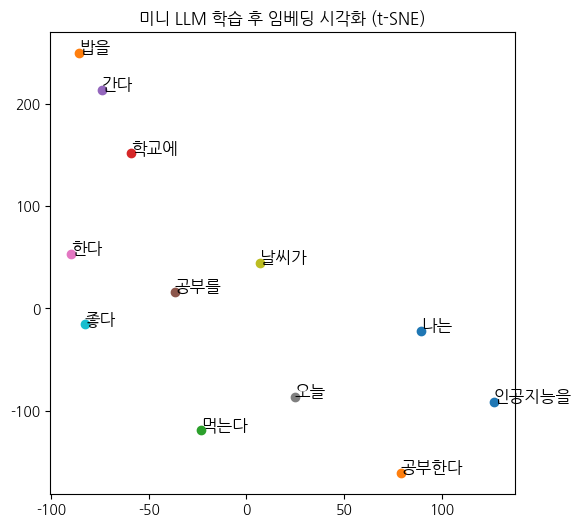

In [116]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

vocab_size = len(vocab)
word_to_id = {w:i for i,w in enumerate(vocab)}
id_to_word = {i:w for i,w in word_to_id.items()}

# 미니 시퀀스 데이터
sentences = [
    "나는 밥을 먹는다",
    "나는 학교에 간다",
    "나는 공부를 한다", 
    "오늘 날씨가 좋다",
    "오늘 인공지능을 공부한다"
]


X_tensor = [torch.tensor(xi).unsqueeze(0) for xi in X]
Y_tensor = [torch.tensor(yi) for yi in Y]

# 미니 LLM 정의
embedding_dim = 8
hidden_dim = 16

class MiniLLM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size+1, embedding_dim)
        self.fc1 = nn.Linear(embedding_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, vocab_size+1)

    def forward(self, x):
        x = self.embedding(x)
        x = x.mean(dim=1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

model = MiniLLM(vocab_size, embedding_dim, hidden_dim)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# 학습
print("학습 시작...")
for epoch in range(200):
    total_loss = 0
    for xi, yi in zip(X_tensor, Y_tensor):
        optimizer.zero_grad()
        out = model(xi)
        loss = criterion(out, yi.unsqueeze(0))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")
print("학습 완료")

# 학습 후 임베딩 벡터 확인
embeddings = model.embedding.weight.detach().numpy()
print("\n==== 학습 후 임베딩 벡터 ====")
for i, w in enumerate(vocab):
    print(f"{w}: {np.round(embeddings[i], 3)}")

# 코사인 유사도
cos_sim = cosine_similarity(embeddings)
print("\n==== 코사인 유사도 행렬 ====")
print(np.round(cos_sim, 2))

# t-SNE 시각화
tsne = TSNE(n_components=2, perplexity=2, random_state=42)
emb_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(6,6))
for i, w in enumerate(vocab):
    x, y = emb_2d[i]
    plt.scatter(x, y)
    plt.text(x+0.05, y+0.05, w, fontsize=12)
plt.title("미니 LLM 학습 후 임베딩 시각화 (t-SNE)")
plt.show()